In [89]:
print("Working") # sometimes stuff takes a long time to actually run so this is to see if its actually running or notw


Working


Import stuff

In [90]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns


Combining all of the GaN datasets into one big dataframe.


In [91]:
files = [f"GaN{year}.csv" for year in range(2006, 2025)] #All of the files are named GaN(year).csv so this just gets them looping from the years of 2006 to 2025, and adding GaN and .csv

all_dataframes = []
for f in files:
    try:
        df = pd.read_csv(f, engine='python')
        all_dataframes.append(df)
    except pd.errors.ParserError as e:
        print(f"Warning: Could not read file {f} due to ParserError: {e}. Skipping this file.")
    except FileNotFoundError:
        print(f"Warning: File {f} not found. Skipping this file.")

if all_dataframes:
    star_data = pd.concat(all_dataframes, axis=0) # Changed axis to 0 for row-wise concatenation
else:
    print("No valid dataframes were read. 'star_data' will not be created.")
    star_data = pd.DataFrame() # Initialize as empty DataFrame if no valid data

Take a look at the data!

In [92]:
star_data.head()
star_data.tail()

,ID,ObsType,Latitude,Longitude,Elevation(m),LocalDate,LocalTime,UTDate,UTTime,LimitingMag,SQMReading,SQMSerial,CloudCover,Constellation,SkyComment,LocationComment,Country
14368,313243,GAN,5.795222,100.897428,100.870,2024-01-01,23:56,2024-01-01,15:56,0,NaN,NaN,clear,Orion,Clear\n\nTaurus constellation,Suburban,Malaysia
14369,313241,GAN,42.316822,-71.287746,75.640,2023-12-31,20:13,2024-01-01,01:13,0,NaN,NaN,over 1/2 of sky,Orion,"VERY cloudy, couldn't see a single star",NaN,United States - Massachusetts
14370,313240,GAN,40.439582,-79.989320,244.730,2023-12-31,19:58,2024-01-01,00:58,1,NaN,NaN,1/2 of sky,Pegasus,Thick fluffy clouds with zero haze and mild wi...,Large city with large buildings and plenty of ...,United States - Pennsylvania
14371,291217,GAN,33.989700,35.320200,-1576.590,2024-01-05,09:52,2024-01-05,11:52,7,6.0,0.0,over 1/2 of sky,Orion,Test,Test,Jamaica
14372,283846,GAN,-43.627000,171.656000,321.959,2024-08-22,20:30,2024-08-23,08:00,4,NaN,NaN,over 1/2 of sky,Sagittarius,NaN,suburban town with street lights,New Zealand


Clean the data (the text after dashes or brackets)


In [93]:
#GaN data
if not star_data.empty and "Country" in star_data.columns:
    star_data["Country"] = (
        star_data["Country"]
        .str.split("-", n=1)
        .str[0]
        .str.strip()
    )

In [94]:
star_data.head()
star_data.tail()

,ID,ObsType,Latitude,Longitude,Elevation(m),LocalDate,LocalTime,UTDate,UTTime,LimitingMag,SQMReading,SQMSerial,CloudCover,Constellation,SkyComment,LocationComment,Country
14368,313243,GAN,5.795222,100.897428,100.870,2024-01-01,23:56,2024-01-01,15:56,0,NaN,NaN,clear,Orion,Clear\n\nTaurus constellation,Suburban,Malaysia
14369,313241,GAN,42.316822,-71.287746,75.640,2023-12-31,20:13,2024-01-01,01:13,0,NaN,NaN,over 1/2 of sky,Orion,"VERY cloudy, couldn't see a single star",NaN,United States
14370,313240,GAN,40.439582,-79.989320,244.730,2023-12-31,19:58,2024-01-01,00:58,1,NaN,NaN,1/2 of sky,Pegasus,Thick fluffy clouds with zero haze and mild wi...,Large city with large buildings and plenty of ...,United States
14371,291217,GAN,33.989700,35.320200,-1576.590,2024-01-05,09:52,2024-01-05,11:52,7,6.0,0.0,over 1/2 of sky,Orion,Test,Test,Jamaica
14372,283846,GAN,-43.627000,171.656000,321.959,2024-08-22,20:30,2024-08-23,08:00,4,NaN,NaN,over 1/2 of sky,Sagittarius,NaN,suburban town with street lights,New Zealand


Now for the HDI dataset.

Put the data into a pandas dataframe (its an xlsx file)

In [95]:
hdi=pd.read_excel('HDI.xlsx')

Look at it


In [96]:
hdi.head()

,HDI rank,Country,Value,mmm nmmmmmnnnnmmmmm
0,1.0,Iceland,0.972,NaN
1,2.0,Norway,0.97,NaN
2,2.0,Switzerland,0.97,NaN
3,4.0,Denmark,0.962,NaN
4,5.0,Germany,0.959,NaN


Clean the data.


Remove a glitched column, and stuff in brackets or stuff after dashes

In [97]:
hdi = hdi.drop(columns=["mmm nmmmmmnnnnmmmmm"]) #not sure why but theres a column named this, i have to remove it, its COMPLETELY empty


#HDI data
hdi["Country"] = (
    hdi["Country"]
    .str.replace(r"\s*-\s*.*$", "", regex=True)
    .str.replace(r"\s*\(.*?\)", "", regex=True)
    .str.strip()
)



There are a LOT of countries and territories that either arent in the HDI, or are under a different name. So, all of those countries had to be hard-coded for to combine the datasets properly.

In [98]:
#Countries that have a different name
gan_to_hdi = {
    "Turkey":                                    "Türkiye",
    "Vietnam":                                   "Viet Nam",
    "Russia":                                    "Russian Federation",
    "Macedonia":                                 "North Macedonia",
    "Czech Republic":                            "Czechia",
    "South Korea":                               "Korea",          # HDI: "Korea (Republic of)"
    "North Korea":                               "Korea",          # HDI: "Korea (Democratic People's Rep. of)"
    "The Bahamas":                               "Bahamas",
    "Democratic Republic of the Congo":          "Congo",          # HDI: "Congo (Democratic Republic of the)"
    "Syria":                                     "Syrian Arab Republic",
    "Laos":                                      "Lao People's Democratic Republic",
    "St Vincent and the Grenadines":             "Saint Vincent and the Grenadines",
    "The Gambia":                                "Gambia",
    "Cape Verde":                                "Cabo Verde",
    "St Kitts and Nevis":                        "Saint Kitts and Nevis",
}

#Territories - these will be excluded because the HDI does not calculate these.
territories_to_exclude = {
    "Puerto Rico",
    "Cayman Islands",
    "Taiwan",
    "Greenland",
    "Isle of Man",
    "Virgin Islands",
    "Bermuda",
    "Guam",
    "Martinique",
    "Guernsey",
    "Aruba",
    "New Caledonia",
    "Antarctica",
    "French Polynesia",
    "Reunion",
    "British Indian Ocean Territory",
    "British Virgin Islands",
    "Gibraltar",
    "Cook Islands",
    "Turks and Caicos Islands",
    "Norfolk Island",
    "Baker Island",
    "Pitcairn Islands",
    "Netherlands Antilles",
    "Guadeloupe",
    "Falkland Islands",
    "Wake Island",
    "South Georgia and the South Sandwich Islands",
    "Northern Mariana Islands",
}

if not star_data.empty and "Country" in star_data.columns:
    #Put the renamed ones into the datasets
    star_data["Country"] = star_data["Country"].replace(gan_to_hdi)

    #Delete the territories o7
    star_data = star_data[~star_data["Country"].isin(territories_to_exclude)].reset_index(drop=True)

    # Removed the specific filter for 'United States' to retain all valid countries
else:
    print("Warning: star_data is empty or 'Country' column is missing. Skipping country-specific filtering and renaming.")

Take a look at the cleaned up data


In [99]:
hdi.head()

,HDI rank,Country,Value
0,1.0,Iceland,0.972
1,2.0,Norway,0.97
2,2.0,Switzerland,0.97
3,4.0,Denmark,0.962
4,5.0,Germany,0.959


Merge them

In [100]:
hdi.columns = hdi.columns.str.strip()

if "Value" not in star_data.columns: #You get multiple columns if you accidentally run this block twice, so this double checks
    star_data = star_data.merge(
        hdi[["Country", "Value"]],
        on="Country",
        how="left"
    )



Take a look at our cleaned and combined data!

In [101]:
star_data.head()
star_data.tail()

,ID,ObsType,Latitude,Longitude,Elevation(m),LocalDate,LocalTime,UTDate,UTTime,LimitingMag,SQMReading,SQMSerial,CloudCover,Constellation,SkyComment,LocationComment,Country,Value
308869,313243,GAN,5.795222,100.897428,100.870,2024-01-01,23:56,2024-01-01,15:56,0,NaN,NaN,clear,Orion,Clear\n\nTaurus constellation,Suburban,Malaysia,0.819
308870,313241,GAN,42.316822,-71.287746,75.640,2023-12-31,20:13,2024-01-01,01:13,0,NaN,NaN,over 1/2 of sky,Orion,"VERY cloudy, couldn't see a single star",NaN,United States,0.938
308871,313240,GAN,40.439582,-79.989320,244.730,2023-12-31,19:58,2024-01-01,00:58,1,NaN,NaN,1/2 of sky,Pegasus,Thick fluffy clouds with zero haze and mild wi...,Large city with large buildings and plenty of ...,United States,0.938
308872,291217,GAN,33.989700,35.320200,-1576.590,2024-01-05,09:52,2024-01-05,11:52,7,6.0,0.0,over 1/2 of sky,Orion,Test,Test,Jamaica,0.72
308873,283846,GAN,-43.627000,171.656000,321.959,2024-08-22,20:30,2024-08-23,08:00,4,NaN,NaN,over 1/2 of sky,Sagittarius,NaN,suburban town with street lights,New Zealand,0.938


Debug stuff, so I can look at the dataset and make sure everythings going right. You dont need to look at this unless you want to see the data.


In [102]:
import random

filename = f"star_data_with_hdi_{random.randint(100000, 999999)}.csv" #make a csv file output with a random number so there is no output
star_data.to_csv(filename, index=False)

print("Saved as:", filename)


Saved as: star_data_with_hdi_497515.csv


More preprocessing needs to be done

<Axes: xlabel='Value', ylabel='LimitingMag'>

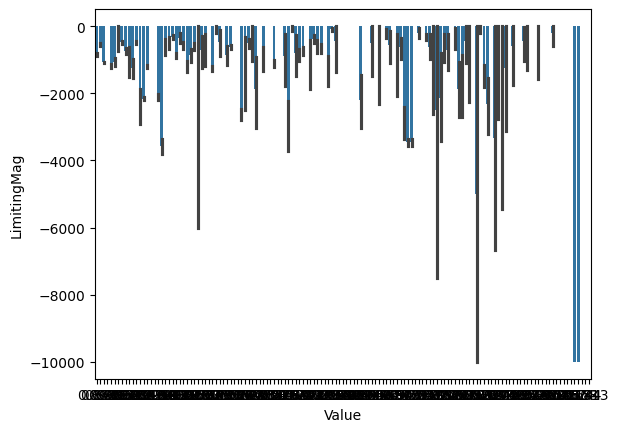

In [103]:
sns.barplot(x=star_data['Value'],y=star_data['LimitingMag'],data=star_data)


Now let's try doing it with all of the countries! The first thing I want to try and do is try to average all the radiances of each country. We have done model development, however doing more simple linear and logarithmic regression mapped would be more significant and helpful for the research topic.

In [104]:
numerical_cols = star_data.select_dtypes(include=['number']).columns
if 'ID' in numerical_cols: # ID is an identifier, not a measurement to average
    numerical_cols = numerical_cols.drop('ID')

# Group by 'Country' and calculate the mean for numerical columns
avg_star_data_by_country = star_data.groupby('Country')[numerical_cols].mean().reset_index()

print("Averaged data by country:")
print(avg_star_data_by_country.head())

Averaged data by country:
       Country   Latitude  Longitude  Elevation(m)  LimitingMag   SQMReading
0  Afghanistan  33.587369  66.380438   1227.281538  -764.000000    20.565000
1      Albania  41.053635  20.320385    456.519143     4.000000          NaN
2      Algeria  35.032425   5.192959    653.279978 -2902.831081    17.592273
3      Andorra  38.452310  -2.053922    333.238700     3.000000  1980.000000
4       Angola  -8.827640  15.307900    329.955000 -4998.000000          NaN


In [105]:
# First, filter the original star_data to only include valid LimitingMag values (0-10)
star_data_valid_mag = star_data[(star_data['LimitingMag'] >= 0) & (star_data['LimitingMag'] <= 10)].copy()

# Identify numerical columns from this filtered dataframe for averaging
numerical_cols_valid_mag = star_data_valid_mag.select_dtypes(include=['number']).columns
if 'ID' in numerical_cols_valid_mag: # ID is an identifier, not a measurement to average
    numerical_cols_valid_mag = numerical_cols_valid_mag.drop('ID')

# Group by 'Country' and calculate the mean for these numerical columns
avg_star_data_by_country_recalculated = star_data_valid_mag.groupby('Country')[numerical_cols_valid_mag].mean().reset_index()

print("Recalculated averaged data by country (ignoring invalid LimitingMag values):")
display(avg_star_data_by_country_recalculated.head())

Recalculated averaged data by country (ignoring invalid LimitingMag values):


,Country,Latitude,Longitude,Elevation(m),LimitingMag,SQMReading
0,Afghanistan,33.752183,66.544792,1264.002500,5.583333,20.565000
1,Albania,41.053635,20.320385,456.519143,4.000000,NaN
2,Algeria,34.521864,4.696883,650.071683,3.219048,17.592273
3,Andorra,38.452310,-2.053922,333.238700,3.000000,1980.000000
4,Angola,-8.845960,17.388300,659.880000,3.000000,NaN


In [106]:
# Filter out 'LimitingMag' values that are below 0 or above 10 so we dont get those cursed values.
avg_star_data_by_country_filtered = avg_star_data_by_country[(avg_star_data_by_country['LimitingMag'] >= 0) & (avg_star_data_by_country['LimitingMag'] <= 10)]

print("Averaged data by country after filtering LimitingMag:")
display(avg_star_data_by_country_filtered.head())

Averaged data by country after filtering LimitingMag:


,Country,Latitude,Longitude,Elevation(m),LimitingMag,SQMReading
1,Albania,41.053635,20.320385,456.519143,4.000000,NaN
3,Andorra,38.452310,-2.053922,333.238700,3.000000,1980.0
6,Armenia,40.371133,44.631433,1178.556667,2.333333,NaN
13,Barbados,13.225533,-59.638667,26.215800,5.333333,21.0
16,Belize,18.094000,-88.398040,-158.072000,4.400000,NaN


In [107]:
# Calculate total data points per country from the original star_data
total_data_points_per_country = star_data.groupby('Country').size().reset_index(name='total_data_points')

# Calculate valid data points per country from the filtered star_data_valid_mag
valid_data_points_per_country = star_data_valid_mag.groupby('Country').size().reset_index(name='valid_data_points')

# Merge total data points into the averaged DataFrame
avg_star_data_by_country_recalculated = avg_star_data_by_country_recalculated.merge(
    total_data_points_per_country, on='Country', how='left'
)

# Merge valid data points to calculate dropped ones
avg_star_data_by_country_recalculated = avg_star_data_by_country_recalculated.merge(
    valid_data_points_per_country, on='Country', how='left'
)

# Calculate dropped data points
avg_star_data_by_country_recalculated['dropped_data_points'] = \
    avg_star_data_by_country_recalculated['total_data_points'] - avg_star_data_by_country_recalculated['valid_data_points']

# Fill any NaN in 'valid_data_points' or 'dropped_data_points' with 0 (for countries with no valid data)
avg_star_data_by_country_recalculated['valid_data_points'] = avg_star_data_by_country_recalculated['valid_data_points'].fillna(0).astype(int)
avg_star_data_by_country_recalculated['dropped_data_points'] = avg_star_data_by_country_recalculated['dropped_data_points'].fillna(avg_star_data_by_country_recalculated['total_data_points']).astype(int)

print("Averaged data with total and dropped data points:")
display(avg_star_data_by_country_recalculated.head())

Averaged data with total and dropped data points:


,Country,Latitude,Longitude,Elevation(m),LimitingMag,SQMReading,total_data_points,valid_data_points,dropped_data_points
0,Afghanistan,33.752183,66.544792,1264.002500,5.583333,20.565000,13,12,1
1,Albania,41.053635,20.320385,456.519143,4.000000,NaN,7,7,0
2,Algeria,34.521864,4.696883,650.071683,3.219048,17.592273,148,105,43
3,Andorra,38.452310,-2.053922,333.238700,3.000000,1980.000000,4,4,0
4,Angola,-8.845960,17.388300,659.880000,3.000000,NaN,2,1,1


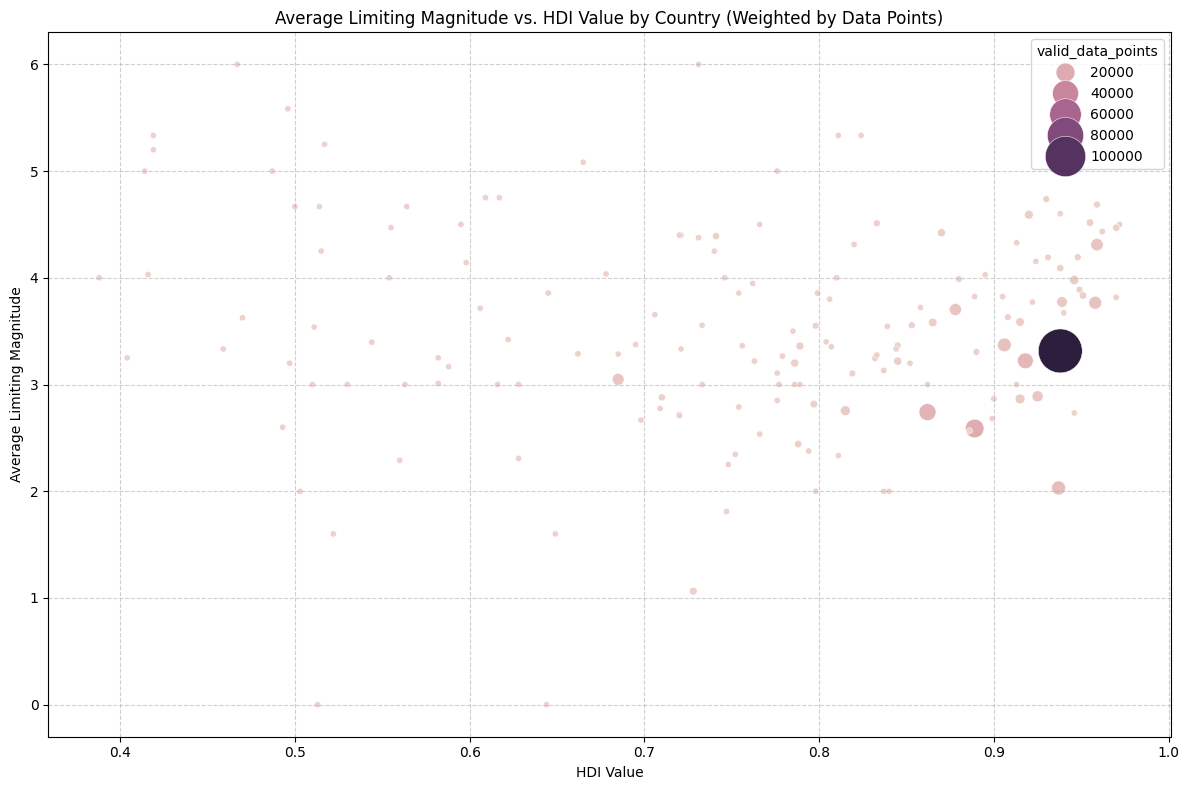

In [108]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure 'Value' column is present in avg_star_data_by_country_recalculated
# This step is added to address the ValueError: 'Value' column not found.
if 'Value' not in avg_star_data_by_country_recalculated.columns:
    avg_star_data_by_country_recalculated = avg_star_data_by_country_recalculated.merge(
        hdi[['Country', 'Value']],
        on='Country',
        how='left'
    )

# Convert 'Value' column to numeric, coercing errors to NaN
avg_star_data_by_country_recalculated['Value'] = pd.to_numeric(avg_star_data_by_country_recalculated['Value'], errors='coerce')

# Drop rows where 'Value' or 'LimitingMag' are NaN (which could be a result of coercion)
# Also ensure 'valid_data_points' is not NaN if used for size/hue
plot_data = avg_star_data_by_country_recalculated.dropna(subset=['Value', 'LimitingMag', 'valid_data_points']).copy()

# Create a scatter plot of LimitingMag vs. Value, with marker size based on valid_data_points
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='Value',
    y='LimitingMag',
    size='valid_data_points',  # Use valid_data_points to determine marker size
    sizes=(20, 1000),         # Define the range of marker sizes
    hue='valid_data_points',  # Color points by valid_data_points for better visual differentiation
    data=plot_data,
    legend='brief'
)

plt.title('Average Limiting Magnitude vs. HDI Value by Country (Weighted by Data Points)')
plt.xlabel('HDI Value')
plt.ylabel('Average Limiting Magnitude')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

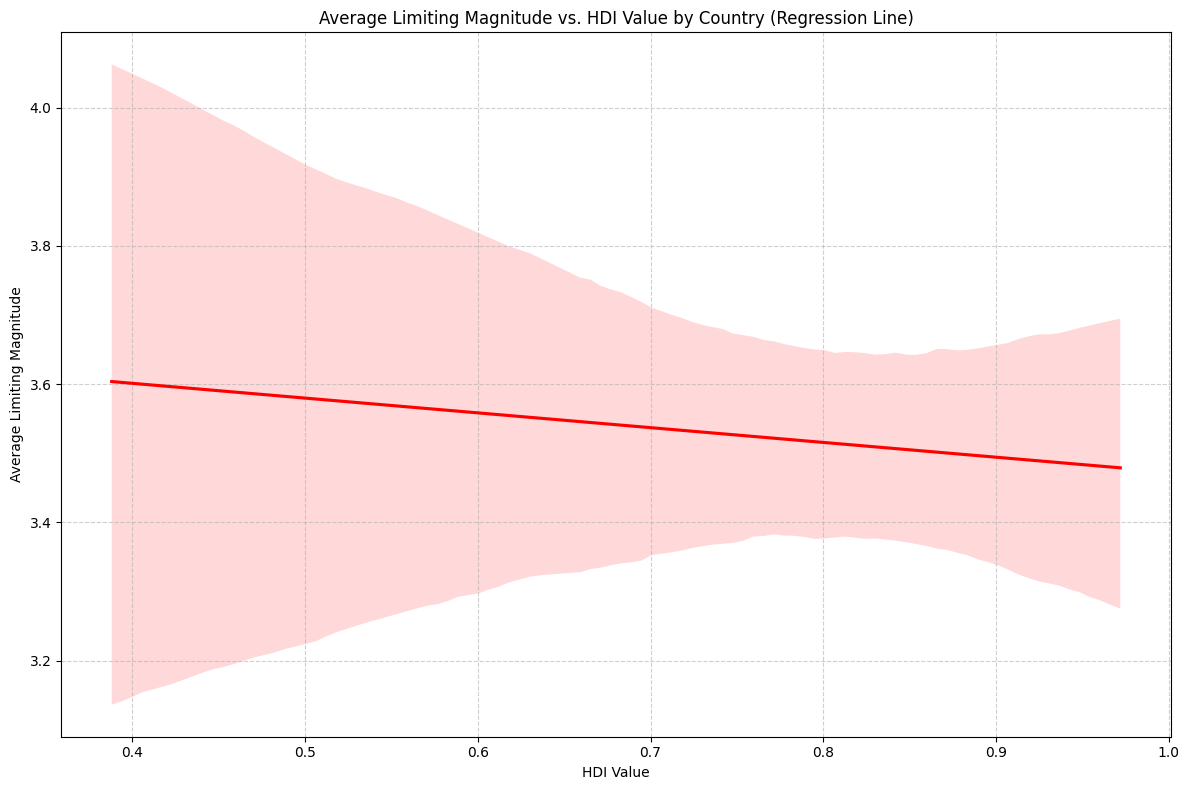

In [109]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Assuming plot_data is already defined and cleaned from previous steps
# plot_data contains 'Value' (HDI) and 'LimitingMag' (average for country)

plt.figure(figsize=(12, 8))
sns.regplot(
    x='Value',
    y='LimitingMag',
    data=plot_data,
    scatter=False, # Only show the line, not the individual points
    ci=95,         # Show 95% confidence interval for the regression line
    line_kws={'color': 'red'} # Customize line color
)

plt.title('Average Limiting Magnitude vs. HDI Value by Country (Regression Line)')
plt.xlabel('HDI Value')
plt.ylabel('Average Limiting Magnitude')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Now, lets try graphing the same thing BUT without averaging.


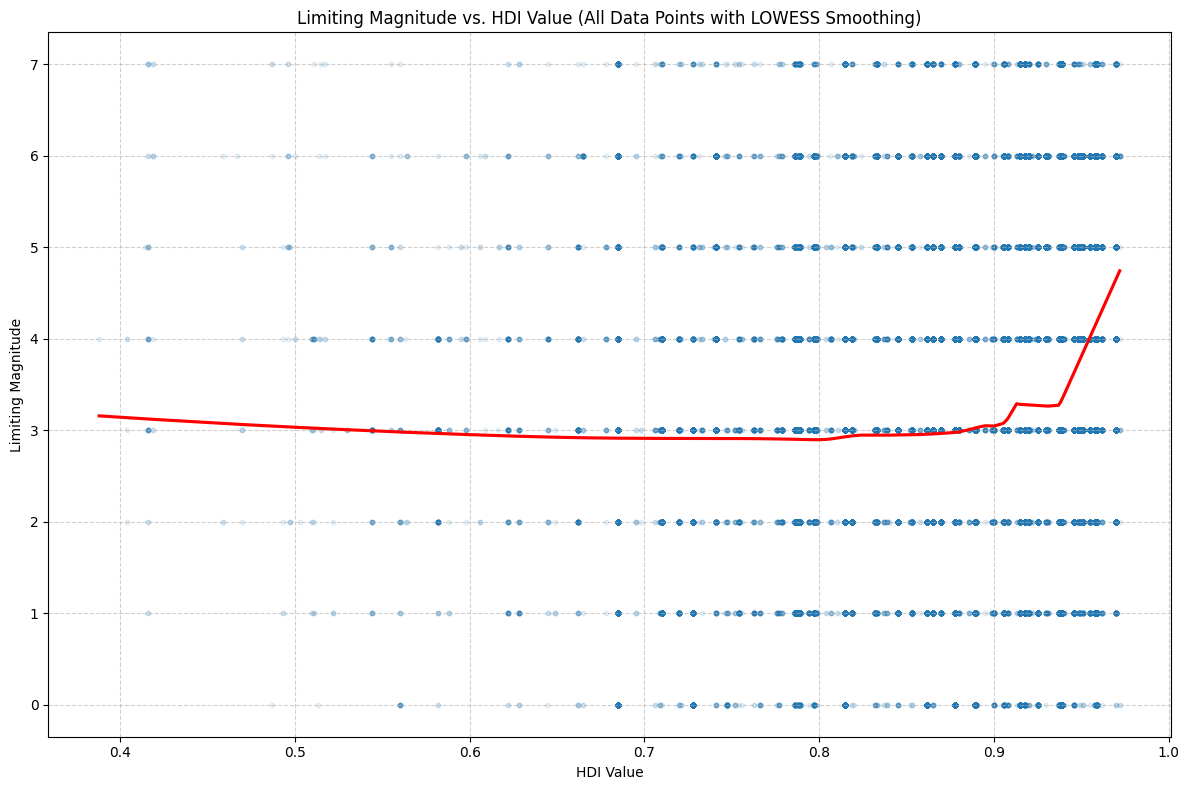

In [110]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure 'Value' column is present in star_data_valid_mag
# This step merges the HDI 'Value' back into the filtered star_data
if 'Value' not in star_data_valid_mag.columns:
    star_data_valid_mag_with_hdi = star_data_valid_mag.merge(
        hdi[['Country', 'Value']],
        on='Country',
        how='left'
    )
else:
    star_data_valid_mag_with_hdi = star_data_valid_mag.copy()

# Convert 'Value' column to numeric, coercing errors to NaN
star_data_valid_mag_with_hdi['Value'] = pd.to_numeric(star_data_valid_mag_with_hdi['Value'], errors='coerce')

# Drop rows where 'Value' or 'LimitingMag' are NaN for plotting
plot_data_raw = star_data_valid_mag_with_hdi.dropna(subset=['Value', 'LimitingMag']).copy()

# Create a scatter plot of LimitingMag vs. Value with a smoothed regression line (LOWESS)
plt.figure(figsize=(12, 8))
sns.regplot(
    x='Value',
    y='LimitingMag',
    data=plot_data_raw,
    scatter_kws={'alpha': 0.1, 's': 10}, # Make points translucent and smaller for large datasets
    line_kws={'color': 'red'},          # Customize line color
    lowess=True                          # Use LOWESS for a smoothed, non-linear regression line
)

plt.title('Limiting Magnitude vs. HDI Value (All Data Points with LOWESS Smoothing)')
plt.xlabel('HDI Value')
plt.ylabel('Limiting Magnitude')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Logarithmic Regression (Averaged Data)

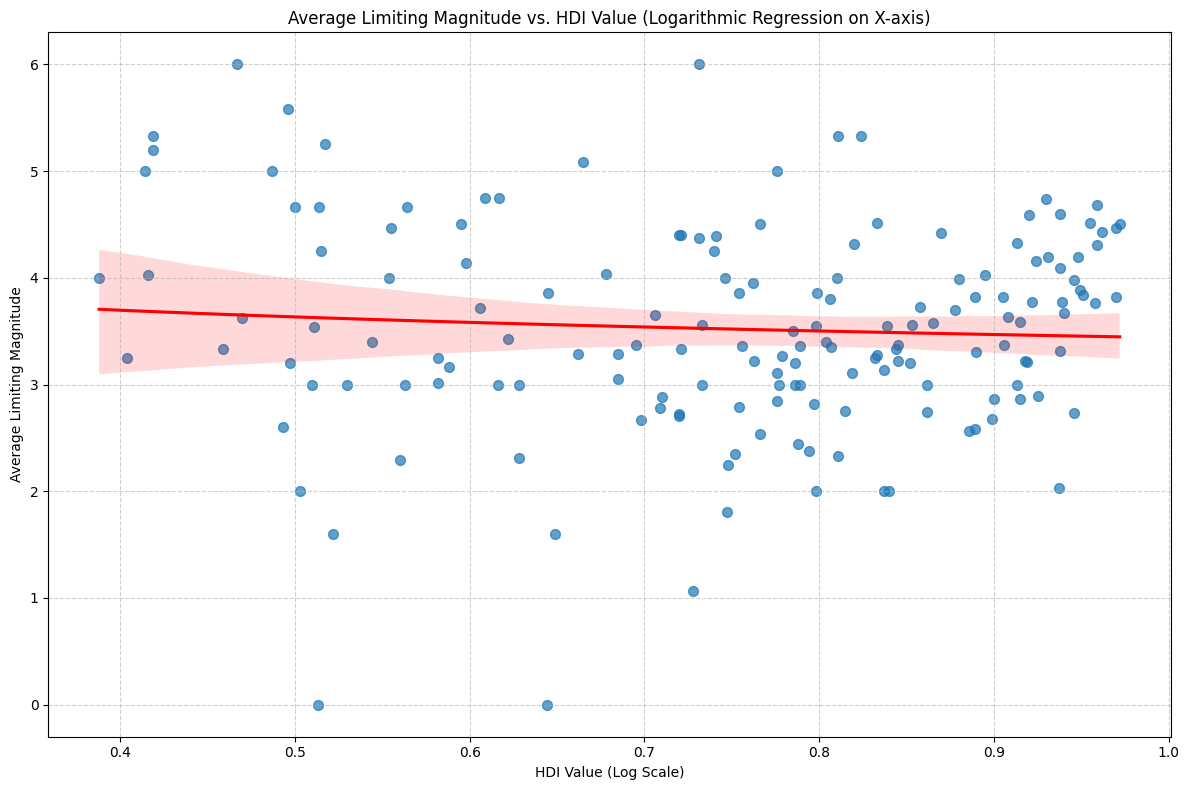

In [111]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Assuming plot_data is already defined and cleaned from previous steps
# plot_data contains 'Value' (HDI) and 'LimitingMag' (average for country)

# Filter out any zero or negative 'Value' for logarithmic transformation
plot_data_log = plot_data[plot_data['Value'] > 0].copy()

plt.figure(figsize=(12, 8))
sns.regplot(
    x='Value',
    y='LimitingMag',
    data=plot_data_log,
    scatter_kws={'s': 50, 'alpha': 0.7},
    line_kws={'color': 'red'},
    logx=True, # Apply logarithmic transformation to the x-axis
    ci=95      # Show 95% confidence interval for the regression line
)

plt.title('Average Limiting Magnitude vs. HDI Value (Logarithmic Regression on X-axis)')
plt.xlabel('HDI Value (Log Scale)')
plt.ylabel('Average Limiting Magnitude')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Evaluating Regression Fit (R-squared)

To understand how well our models explain the relationship between HDI Value and Limiting Magnitude, we can calculate the R-squared value for both the linear and logarithmic regressions.

In [112]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import numpy as np

# --- Linear Regression R-squared (Averaged Data) ---

# Prepare data for linear regression
X_linear = plot_data[['Value']].values
y_linear = plot_data['LimitingMag'].values

# Create and fit the linear regression model
linear_model = LinearRegression()
linear_model.fit(X_linear, y_linear)

# Make predictions
y_linear_pred = linear_model.predict(X_linear)

# Calculate R-squared
r_squared_linear = r2_score(y_linear, y_linear_pred)

print(f"R-squared for Linear Regression (Averaged Data): {r_squared_linear:.4f}")

R-squared for Linear Regression (Averaged Data): 0.0012


In [113]:
# --- Logarithmic Regression R-squared (Averaged Data) ---

# Prepare data for logarithmic regression on X-axis
# Ensure 'Value' is greater than 0 before taking log
X_log = np.log(plot_data_log[['Value']]).values
y_log = plot_data_log['LimitingMag'].values

# Create and fit the linear regression model on the log-transformed x-axis
log_model = LinearRegression()
log_model.fit(X_log, y_log)

# Make predictions
y_log_pred = log_model.predict(X_log)

# Calculate R-squared
r_squared_log = r2_score(y_log, y_log_pred)

print(f"R-squared for Logarithmic Regression (Averaged Data): {r_squared_log:.4f}")

R-squared for Logarithmic Regression (Averaged Data): 0.0044


## Extended Analysis: Hyperparameter Tuning, Advanced Models & Visualization

This section builds on the regression analysis above, adding:
- Polynomial regression with cross-validated degree selection
- Random Forest & Gradient Boosting with Optuna hyperparameter tuning
- Spearman/Pearson correlation tests
- Residual diagnostics
- Country-level visualizations (top/bottom performers)
- Feature importance analysis
- A final results summary table

In [114]:
# ── Imports for the extended analysis ──────────────────────────────────────
!pip install optuna
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from scipy import stats
from scipy.stats import pearsonr, spearmanr

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, KFold, GridSearchCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

print("All imports successful.")

All imports successful.


---
## 1. Statistical Correlation Tests

Before modelling, we formally test whether HDI and Limiting Magnitude are correlated, using both Pearson (linear) and Spearman (rank-based, non-parametric) tests.

In [115]:
# ── 1. Pearson & Spearman Correlation ──────────────────────────────────────
# Use the averaged, cleaned data (plot_data) from earlier cells

X_vals = plot_data['Value'].values       # HDI
y_vals = plot_data['LimitingMag'].values # Avg Limiting Magnitude

pearson_r, pearson_p  = pearsonr(X_vals, y_vals)
spearman_r, spearman_p = spearmanr(X_vals, y_vals)

print("=" * 55)
print("  Statistical Correlation: HDI  vs  Limiting Magnitude")
print("=" * 55)
print(f"  Pearson  r = {pearson_r:+.4f}   p = {pearson_p:.4e}")
print(f"  Spearman r = {spearman_r:+.4f}   p = {spearman_p:.4e}")
print()
sig = lambda p: "✓ Significant (p < 0.05)" if p < 0.05 else "✗ Not significant"
print(f"  Pearson  → {sig(pearson_p)}")
print(f"  Spearman → {sig(spearman_p)}")
print()
print("Interpretation:")
if pearson_r < 0:
    print("  Negative correlation: Higher HDI → lower Limiting Magnitude")
    print("  (i.e. more developed countries have worse (brighter) skies)")
else:
    print("  Positive correlation: Higher HDI → higher Limiting Magnitude")
    print("  (i.e. more developed countries have better (darker) skies)")


  Statistical Correlation: HDI  vs  Limiting Magnitude
  Pearson  r = -0.0342   p = 6.6503e-01
  Spearman r = +0.0272   p = 7.3007e-01

  Pearson  → ✗ Not significant
  Spearman → ✗ Not significant

Interpretation:
  Negative correlation: Higher HDI → lower Limiting Magnitude
  (i.e. more developed countries have worse (brighter) skies)


---
## 2. Polynomial Regression — Degree Selection via Cross-Validation

Linear and logarithmic regressions may not capture the full curve. We try polynomial degrees 1–6 and pick the best using 5-fold CV RMSE.

Best polynomial degree : 4
Cross-validated RMSE   : 0.9479
Cross-validated R²     : 0.0293



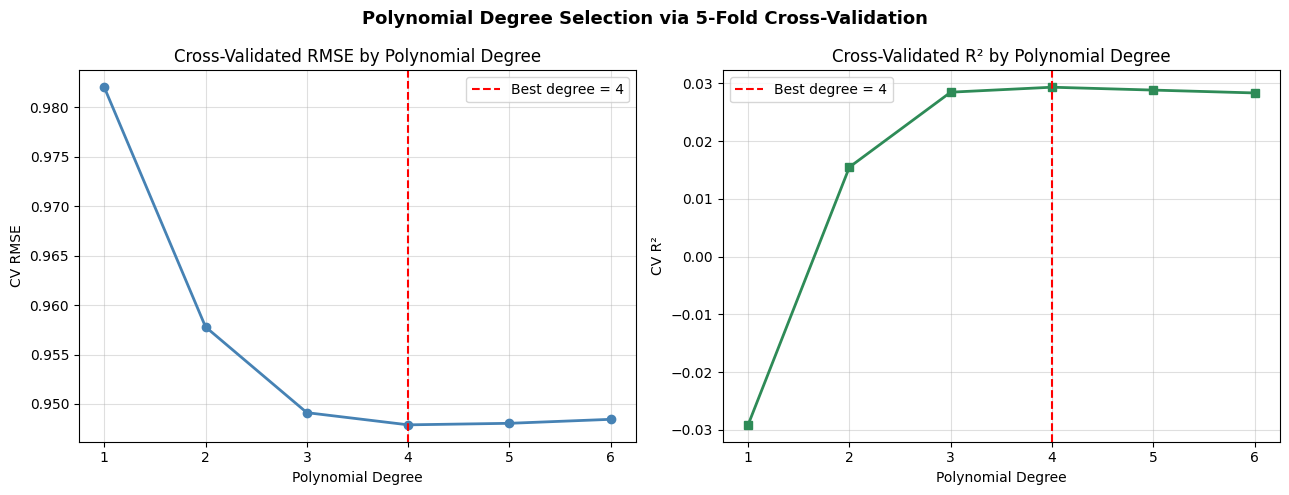

In [116]:
# ── 2. Polynomial Regression Degree Selection ───────────────────────────────
X_1d = X_vals.reshape(-1, 1)
kf   = KFold(n_splits=5, shuffle=True, random_state=42)

degrees   = range(1, 7)
cv_rmse   = []
cv_r2     = []

for deg in degrees:
    pipe = Pipeline([
        ('poly',   PolynomialFeatures(degree=deg, include_bias=False)),
        ('scaler', StandardScaler()),
        ('reg',    Ridge(alpha=1.0))
    ])
    neg_mse = cross_val_score(pipe, X_1d, y_vals, cv=kf,
                               scoring='neg_mean_squared_error')
    r2_cv   = cross_val_score(pipe, X_1d, y_vals, cv=kf, scoring='r2')
    cv_rmse.append(np.sqrt(-neg_mse.mean()))
    cv_r2.append(r2_cv.mean())

best_deg  = degrees[np.argmin(cv_rmse)]
best_rmse = min(cv_rmse)
best_r2   = cv_r2[np.argmin(cv_rmse)]

print(f"Best polynomial degree : {best_deg}")
print(f"Cross-validated RMSE   : {best_rmse:.4f}")
print(f"Cross-validated R²     : {best_r2:.4f}")
print()

# ── Plot: RMSE & R² by degree ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(list(degrees), cv_rmse, 'o-', color='steelblue', linewidth=2)
axes[0].axvline(best_deg, color='red', linestyle='--', label=f'Best degree = {best_deg}')
axes[0].set_xlabel('Polynomial Degree'); axes[0].set_ylabel('CV RMSE')
axes[0].set_title('Cross-Validated RMSE by Polynomial Degree')
axes[0].legend(); axes[0].grid(alpha=0.4)

axes[1].plot(list(degrees), cv_r2, 's-', color='seagreen', linewidth=2)
axes[1].axvline(best_deg, color='red', linestyle='--', label=f'Best degree = {best_deg}')
axes[1].set_xlabel('Polynomial Degree'); axes[1].set_ylabel('CV R²')
axes[1].set_title('Cross-Validated R² by Polynomial Degree')
axes[1].legend(); axes[1].grid(alpha=0.4)

plt.suptitle('Polynomial Degree Selection via 5-Fold Cross-Validation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('poly_degree_selection.png', dpi=150, bbox_inches='tight')
plt.show()


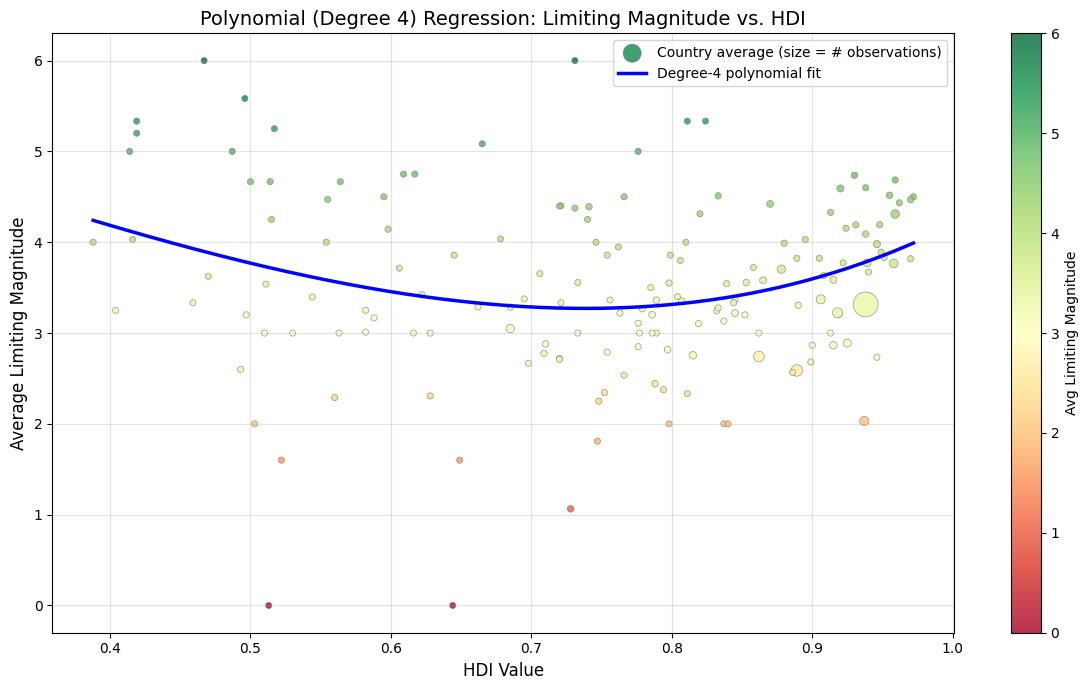

Polynomial (deg 4) — Training R²: 0.0790  |  RMSE: 0.9303


In [117]:
# ── Fit the best polynomial model and plot ──────────────────────────────────
best_pipe = Pipeline([
    ('poly',   PolynomialFeatures(degree=best_deg, include_bias=False)),
    ('scaler', StandardScaler()),
    ('reg',    Ridge(alpha=1.0))
])
best_pipe.fit(X_1d, y_vals)

x_range    = np.linspace(X_vals.min(), X_vals.max(), 300).reshape(-1, 1)
y_poly_fit = best_pipe.predict(x_range)
y_poly_pred = best_pipe.predict(X_1d)

plt.figure(figsize=(12, 7))
plt.scatter(X_vals, y_vals,
            s=plot_data['valid_data_points'] / plot_data['valid_data_points'].max() * 300 + 20,
            c=y_vals, cmap='RdYlGn', alpha=0.8, edgecolors='grey', linewidth=0.5,
            label='Country average (size = # observations)')
plt.plot(x_range, y_poly_fit, 'b-', linewidth=2.5,
         label=f'Degree-{best_deg} polynomial fit')
plt.colorbar(label='Avg Limiting Magnitude')
plt.xlabel('HDI Value', fontsize=12)
plt.ylabel('Average Limiting Magnitude', fontsize=12)
plt.title(f'Polynomial (Degree {best_deg}) Regression: Limiting Magnitude vs. HDI', fontsize=14)
plt.legend(); plt.grid(alpha=0.35)
plt.tight_layout()
plt.savefig('poly_regression_fit.png', dpi=150, bbox_inches='tight')
plt.show()

r2_poly = r2_score(y_vals, y_poly_pred)
rmse_poly = np.sqrt(mean_squared_error(y_vals, y_poly_pred))
print(f"Polynomial (deg {best_deg}) — Training R²: {r2_poly:.4f}  |  RMSE: {rmse_poly:.4f}")


---
## 3. Random Forest — Optuna Hyperparameter Tuning

We use Optuna (Bayesian optimisation) to efficiently search for the best Random Forest hyperparameters, minimising 5-fold cross-validated RMSE.

In [118]:
# ── 3. Random Forest with Optuna Tuning ─────────────────────────────────────
def rf_objective(trial):
    params = dict(
        n_estimators     = trial.suggest_int('n_estimators', 50, 600),
        max_depth        = trial.suggest_int('max_depth', 2, 20),
        min_samples_split= trial.suggest_int('min_samples_split', 2, 20),
        min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 15),
        max_features     = trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        random_state     = 42
    )
    model = RandomForestRegressor(**params)
    neg_mse = cross_val_score(model, X_1d, y_vals, cv=kf,
                               scoring='neg_mean_squared_error')
    return np.sqrt(-neg_mse.mean())

rf_study = optuna.create_study(direction='minimize')
rf_study.optimize(rf_objective, n_trials=80, show_progress_bar=False)

print("Best RF hyperparameters:")
for k, v in rf_study.best_params.items():
    print(f"  {k:25s}: {v}")
print(f"\nBest CV RMSE: {rf_study.best_value:.4f}")


Best RF hyperparameters:
  n_estimators             : 74
  max_depth                : 2
  min_samples_split        : 9
  min_samples_leaf         : 6
  max_features             : None

Best CV RMSE: 0.9479


In [119]:
# ── Train final RF model with best params ───────────────────────────────────
rf_best = RandomForestRegressor(**rf_study.best_params, random_state=42)
rf_best.fit(X_1d, y_vals)

y_rf_pred  = rf_best.predict(X_1d)
r2_rf      = r2_score(y_vals, y_rf_pred)
rmse_rf    = np.sqrt(mean_squared_error(y_vals, y_rf_pred))
cv_rf_r2   = cross_val_score(rf_best, X_1d, y_vals, cv=kf, scoring='r2').mean()
cv_rf_rmse = np.sqrt(-cross_val_score(rf_best, X_1d, y_vals, cv=kf,
                                       scoring='neg_mean_squared_error').mean())

print(f"Random Forest  —  Training R²: {r2_rf:.4f}  |  Training RMSE: {rmse_rf:.4f}")
print(f"                  CV R²:        {cv_rf_r2:.4f}  |  CV RMSE:        {cv_rf_rmse:.4f}")


Random Forest  —  Training R²: 0.1255  |  Training RMSE: 0.9065
                  CV R²:        0.0174  |  CV RMSE:        0.9479


---
## 4. Gradient Boosting — Optuna Hyperparameter Tuning

In [120]:
# ── 4. Gradient Boosting with Optuna Tuning ─────────────────────────────────
def gb_objective(trial):
    params = dict(
        n_estimators      = trial.suggest_int('n_estimators', 50, 500),
        learning_rate     = trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        max_depth         = trial.suggest_int('max_depth', 2, 8),
        min_samples_split = trial.suggest_int('min_samples_split', 2, 20),
        min_samples_leaf  = trial.suggest_int('min_samples_leaf', 1, 15),
        subsample         = trial.suggest_float('subsample', 0.5, 1.0),
        random_state      = 42
    )
    model = GradientBoostingRegressor(**params)
    neg_mse = cross_val_score(model, X_1d, y_vals, cv=kf,
                               scoring='neg_mean_squared_error')
    return np.sqrt(-neg_mse.mean())

gb_study = optuna.create_study(direction='minimize')
gb_study.optimize(gb_objective, n_trials=80, show_progress_bar=False)

print("Best GB hyperparameters:")
for k, v in gb_study.best_params.items():
    print(f"  {k:25s}: {v}")
print(f"\nBest CV RMSE: {gb_study.best_value:.4f}")


Best GB hyperparameters:
  n_estimators             : 104
  learning_rate            : 0.010476700406167916
  max_depth                : 2
  min_samples_split        : 13
  min_samples_leaf         : 7
  subsample                : 0.6567338935689201

Best CV RMSE: 0.9468


In [121]:
# ── Train final GB model ─────────────────────────────────────────────────────
gb_best = GradientBoostingRegressor(**gb_study.best_params, random_state=42)
gb_best.fit(X_1d, y_vals)

y_gb_pred  = gb_best.predict(X_1d)
r2_gb      = r2_score(y_vals, y_gb_pred)
rmse_gb    = np.sqrt(mean_squared_error(y_vals, y_gb_pred))
cv_gb_r2   = cross_val_score(gb_best, X_1d, y_vals, cv=kf, scoring='r2').mean()
cv_gb_rmse = np.sqrt(-cross_val_score(gb_best, X_1d, y_vals, cv=kf,
                                       scoring='neg_mean_squared_error').mean())

print(f"Gradient Boosting — Training R²: {r2_gb:.4f}  |  Training RMSE: {rmse_gb:.4f}")
print(f"                    CV R²:        {cv_gb_r2:.4f}  |  CV RMSE:        {cv_gb_rmse:.4f}")


Gradient Boosting — Training R²: 0.1162  |  Training RMSE: 0.9113
                    CV R²:        0.0283  |  CV RMSE:        0.9468


---
## 5. Model Comparison — All Models Side by Side

                     MODEL COMPARISON RESULTS
                    Model  Train R²   CV R²  Train RMSE  CV RMSE
       Polynomial (deg 4)    0.0790  0.0293      0.9303   0.9479
Gradient Boosting (tuned)    0.1162  0.0283      0.9113   0.9468
    Random Forest (tuned)    0.1255  0.0174      0.9065   0.9479
   Logarithmic Regression    0.0044 -0.0283      0.9672   0.9813
        Linear Regression    0.0012 -0.0293      0.9688   0.9822


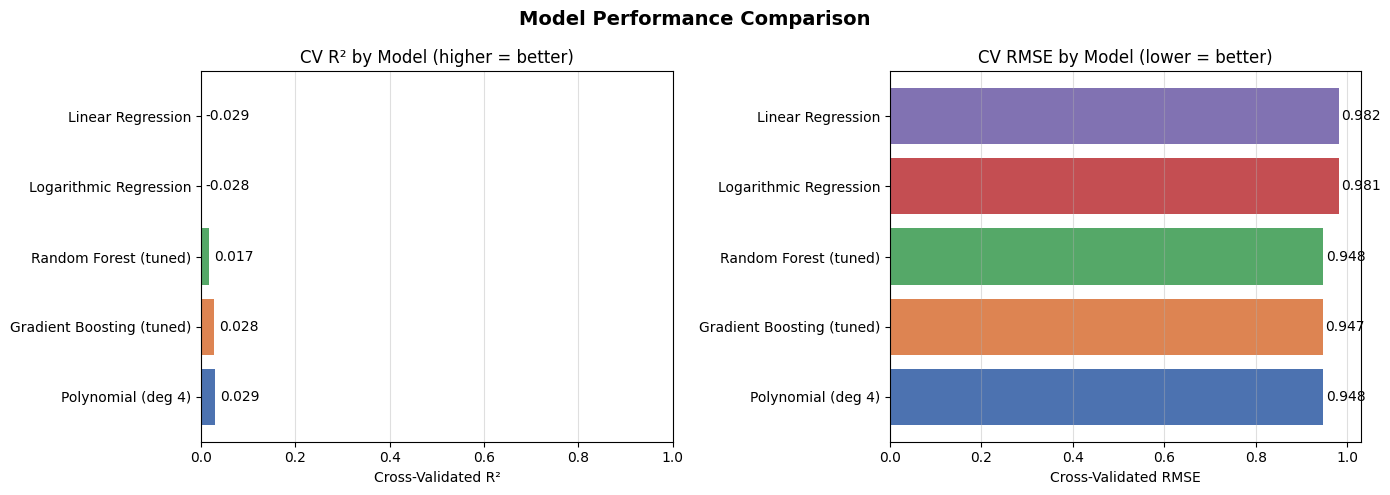

In [122]:
# ── 5. Model Comparison Table & Chart ───────────────────────────────────────

# Rebuild baseline metrics from earlier cells
X_lin  = plot_data[['Value']].values
y_lin  = plot_data['LimitingMag'].values
lm     = LinearRegression().fit(X_lin, y_lin)
y_lm_pred = lm.predict(X_lin)
r2_lin = r2_score(y_lin, y_lm_pred)
rmse_lin = np.sqrt(mean_squared_error(y_lin, y_lm_pred))
cv_lin_r2   = cross_val_score(lm, X_lin, y_lin, cv=kf, scoring='r2').mean()
cv_lin_rmse = np.sqrt(-cross_val_score(lm, X_lin, y_lin, cv=kf,
                                        scoring='neg_mean_squared_error').mean())

X_log2 = np.log(plot_data_log[['Value']]).values
y_log2 = plot_data_log['LimitingMag'].values
lm_log = LinearRegression().fit(X_log2, y_log2)
y_log2_pred = lm_log.predict(X_log2)
r2_log2 = r2_score(y_log2, y_log2_pred)
rmse_log2 = np.sqrt(mean_squared_error(y_log2, y_log2_pred))
cv_log_r2   = cross_val_score(lm_log, X_log2, y_log2, cv=kf, scoring='r2').mean()
cv_log_rmse = np.sqrt(-cross_val_score(lm_log, X_log2, y_log2, cv=kf,
                                        scoring='neg_mean_squared_error').mean())

results = pd.DataFrame({
    'Model':         ['Linear Regression',
                      'Logarithmic Regression',
                      f'Polynomial (deg {best_deg})',
                      'Random Forest (tuned)',
                      'Gradient Boosting (tuned)'],
    'Train R²':      [r2_lin, r2_log2, r2_poly, r2_rf, r2_gb],
    'CV R²':         [cv_lin_r2, cv_log_r2, best_r2, cv_rf_r2, cv_gb_r2],
    'Train RMSE':    [rmse_lin, rmse_log2, rmse_poly, rmse_rf, rmse_gb],
    'CV RMSE':       [cv_lin_rmse, cv_log_rmse, best_rmse, cv_rf_rmse, cv_gb_rmse],
})
results = results.sort_values('CV R²', ascending=False).reset_index(drop=True)

print("=" * 75)
print("                     MODEL COMPARISON RESULTS")
print("=" * 75)
print(results.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
print("=" * 75)

# Bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2']

axes[0].barh(results['Model'], results['CV R²'], color=colors)
axes[0].set_xlabel('Cross-Validated R²'); axes[0].set_title('CV R² by Model (higher = better)')
axes[0].set_xlim(0, 1); axes[0].grid(axis='x', alpha=0.4)
for i, v in enumerate(results['CV R²']):
    axes[0].text(max(v + 0.01, 0.01), i, f'{v:.3f}', va='center')

axes[1].barh(results['Model'], results['CV RMSE'], color=colors)
axes[1].set_xlabel('Cross-Validated RMSE'); axes[1].set_title('CV RMSE by Model (lower = better)')
axes[1].grid(axis='x', alpha=0.4)
for i, v in enumerate(results['CV RMSE']):
    axes[1].text(v + 0.005, i, f'{v:.3f}', va='center')

plt.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 6. Residual Diagnostics

We diagnose the best-fitting model to check for patterns in residuals.

Diagnosing residuals for: Polynomial (deg 4)


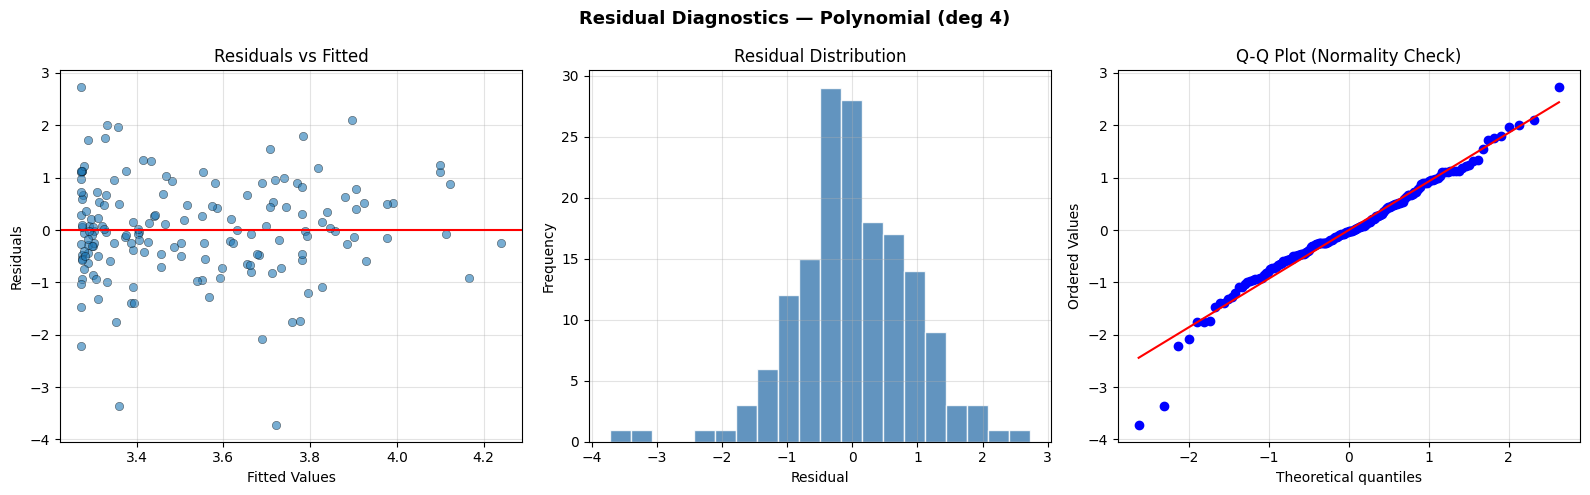


Shapiro-Wilk normality test: W=0.9729, p=0.0027
Residuals deviate from normality (p < 0.05).


In [123]:
# ── 6. Residual Diagnostics (best model by CV R²) ───────────────────────────
best_model_name = results.iloc[0]['Model']
print(f"Diagnosing residuals for: {best_model_name}")

# Pick predictions for whichever was best
model_preds = {
    'Linear Regression'             : y_lm_pred,
    'Logarithmic Regression'        : lm_log.predict(X_log2),
    f'Polynomial (deg {best_deg})'  : y_poly_pred,
    'Random Forest (tuned)'         : y_rf_pred,
    'Gradient Boosting (tuned)'     : y_gb_pred,
}
best_pred  = model_preds[best_model_name]
# align lengths (log model may drop a row)
y_for_diag = y_log2 if best_model_name == 'Logarithmic Regression' else y_vals
residuals  = y_for_diag - best_pred

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Residuals vs fitted
axes[0].scatter(best_pred, residuals, alpha=0.6, edgecolors='k', linewidth=0.4)
axes[0].axhline(0, color='red', linewidth=1.5)
axes[0].set_xlabel('Fitted Values'); axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Fitted'); axes[0].grid(alpha=0.35)

# Histogram of residuals
axes[1].hist(residuals, bins=20, color='steelblue', edgecolor='white', alpha=0.85)
axes[1].set_xlabel('Residual'); axes[1].set_ylabel('Frequency')
axes[1].set_title('Residual Distribution'); axes[1].grid(alpha=0.35)

# Q-Q plot
stats.probplot(residuals, dist='norm', plot=axes[2])
axes[2].set_title('Q-Q Plot (Normality Check)')
axes[2].grid(alpha=0.35)

plt.suptitle(f'Residual Diagnostics — {best_model_name}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('residual_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

# Shapiro-Wilk test
stat, sw_p = stats.shapiro(residuals)
print(f"\nShapiro-Wilk normality test: W={stat:.4f}, p={sw_p:.4f}")
print("Residuals appear normally distributed." if sw_p > 0.05
      else "Residuals deviate from normality (p < 0.05).")


---
## 7. Country-Level Visualizations

Which countries have the darkest and brightest skies? And how do they sit relative to their HDI?

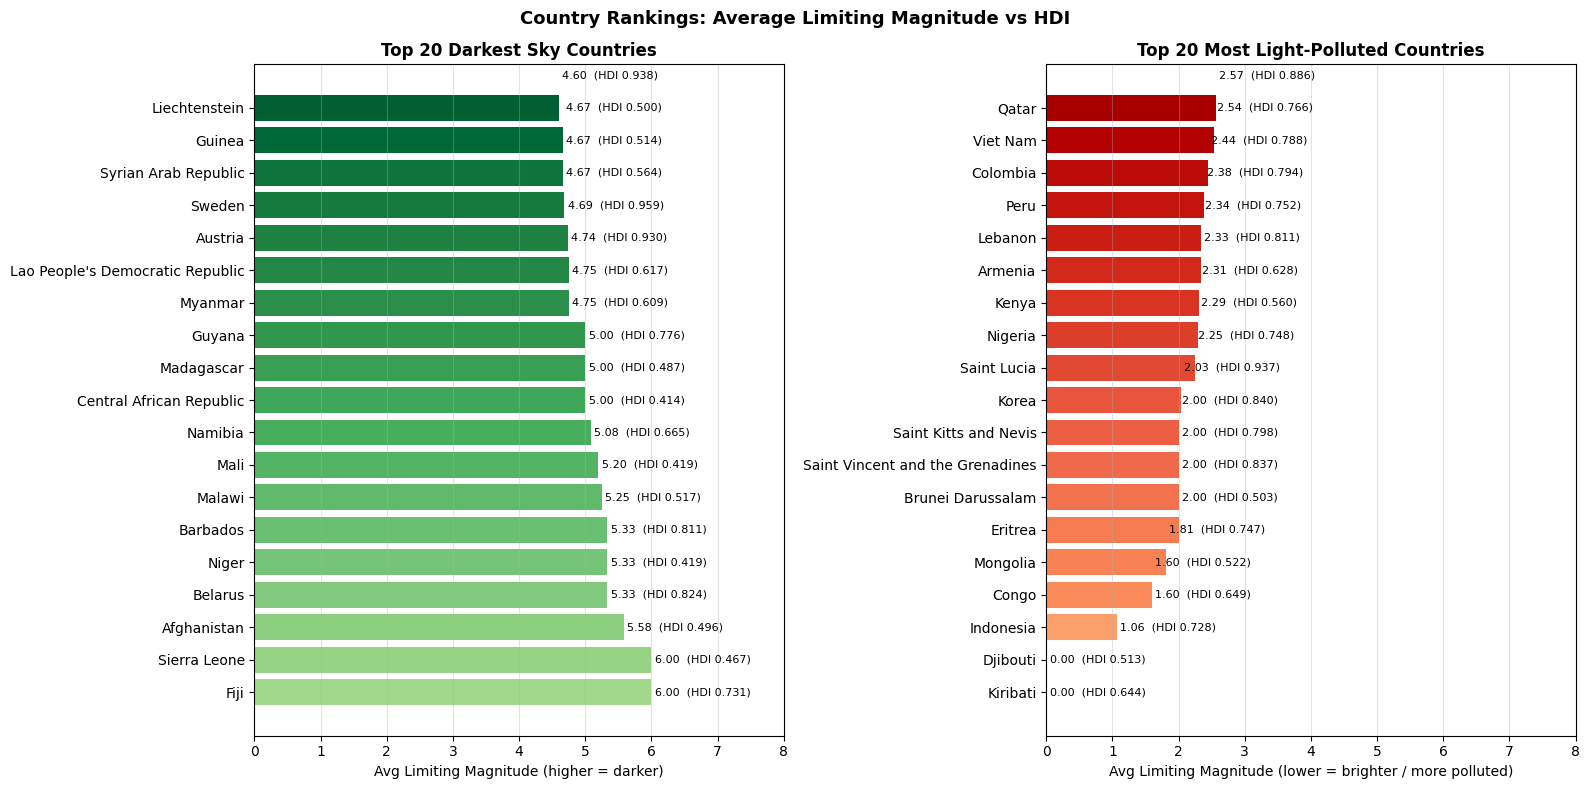

In [124]:
# ── 7a. Top & Bottom 20 Countries by Avg Limiting Magnitude ─────────────────
country_plot = plot_data[['Country', 'LimitingMag', 'Value', 'valid_data_points']].copy()
country_plot = country_plot.sort_values('LimitingMag', ascending=False)

top20    = country_plot.head(20)
bottom20 = country_plot.tail(20).sort_values('LimitingMag')

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Dark sky champions
axes[0].barh(top20['Country'], top20['LimitingMag'],
             color=plt.cm.YlGn(np.linspace(0.4, 0.9, 20)))
axes[0].set_xlabel('Avg Limiting Magnitude (higher = darker)')
axes[0].set_title('Top 20 Darkest Sky Countries', fontweight='bold')
axes[0].grid(axis='x', alpha=0.35)
axes[0].set_xlim(0, 8)
for i, (mag, hdi) in enumerate(zip(top20['LimitingMag'], top20['Value'])):
    axes[0].text(mag + 0.05, i, f'{mag:.2f}  (HDI {hdi:.3f})', va='center', fontsize=8)

# Brightest (most light-polluted)
axes[1].barh(bottom20['Country'], bottom20['LimitingMag'],
             color=plt.cm.OrRd(np.linspace(0.4, 0.9, 20)))
axes[1].set_xlabel('Avg Limiting Magnitude (lower = brighter / more polluted)')
axes[1].set_title('Top 20 Most Light-Polluted Countries', fontweight='bold')
axes[1].grid(axis='x', alpha=0.35)
axes[1].set_xlim(0, 8)
for i, (mag, hdi) in enumerate(zip(bottom20['LimitingMag'], bottom20['Value'])):
    axes[1].text(mag + 0.05, i, f'{mag:.2f}  (HDI {hdi:.3f})', va='center', fontsize=8)

plt.suptitle('Country Rankings: Average Limiting Magnitude vs HDI', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('country_rankings.png', dpi=150, bbox_inches='tight')
plt.show()


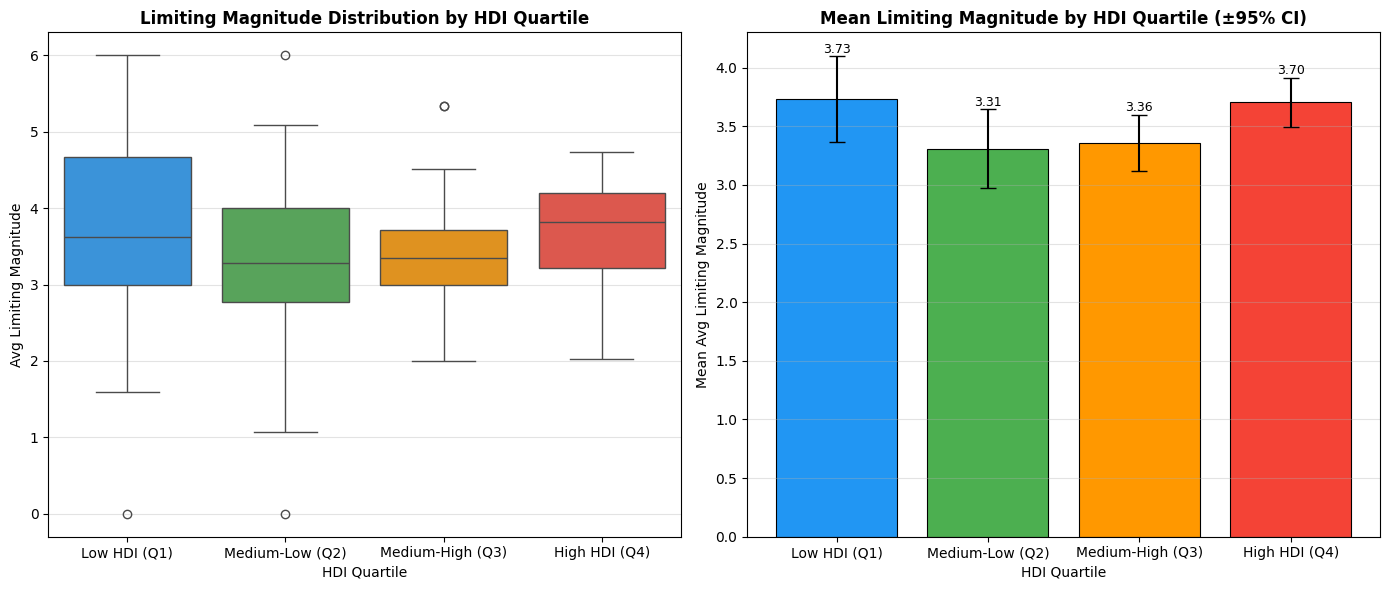

One-way ANOVA across HDI quartiles: F=2.194, p=0.0908
No significant difference across quartiles (p ≥ 0.05).


In [125]:
# ── 7b. HDI Quartile Analysis ────────────────────────────────────────────────
country_plot['HDI_Quartile'] = pd.qcut(
    country_plot['Value'], q=4,
    labels=['Low HDI (Q1)', 'Medium-Low (Q2)', 'Medium-High (Q3)', 'High HDI (Q4)']
)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Box plot
palette = {'Low HDI (Q1)': '#2196F3', 'Medium-Low (Q2)': '#4CAF50',
           'Medium-High (Q3)': '#FF9800', 'High HDI (Q4)': '#F44336'}
sns.boxplot(x='HDI_Quartile', y='LimitingMag', data=country_plot,
            palette=palette, ax=axes[0])
axes[0].set_title('Limiting Magnitude Distribution by HDI Quartile', fontweight='bold')
axes[0].set_xlabel('HDI Quartile'); axes[0].set_ylabel('Avg Limiting Magnitude')
axes[0].grid(axis='y', alpha=0.35)

# Mean + 95% CI per quartile
quartile_stats = country_plot.groupby('HDI_Quartile', observed=True)['LimitingMag'].agg(
    mean='mean', sem=lambda x: x.sem()
).reset_index()
quartile_stats['ci95'] = quartile_stats['sem'] * 1.96

axes[1].bar(quartile_stats['HDI_Quartile'], quartile_stats['mean'],
            yerr=quartile_stats['ci95'], capsize=6,
            color=list(palette.values()), edgecolor='black', linewidth=0.8)
axes[1].set_title('Mean Limiting Magnitude by HDI Quartile (±95% CI)', fontweight='bold')
axes[1].set_xlabel('HDI Quartile'); axes[1].set_ylabel('Mean Avg Limiting Magnitude')
axes[1].grid(axis='y', alpha=0.35)
for i, row in quartile_stats.iterrows():
    axes[1].text(i, row['mean'] + row['ci95'] + 0.03, f"{row['mean']:.2f}", ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('hdi_quartile_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# ANOVA test
groups = [g['LimitingMag'].values for _, g in country_plot.groupby('HDI_Quartile', observed=True)]
f_stat, anova_p = stats.f_oneway(*groups)
print(f"One-way ANOVA across HDI quartiles: F={f_stat:.3f}, p={anova_p:.4f}")
print("Quartile means differ significantly." if anova_p < 0.05
      else "No significant difference across quartiles (p ≥ 0.05).")


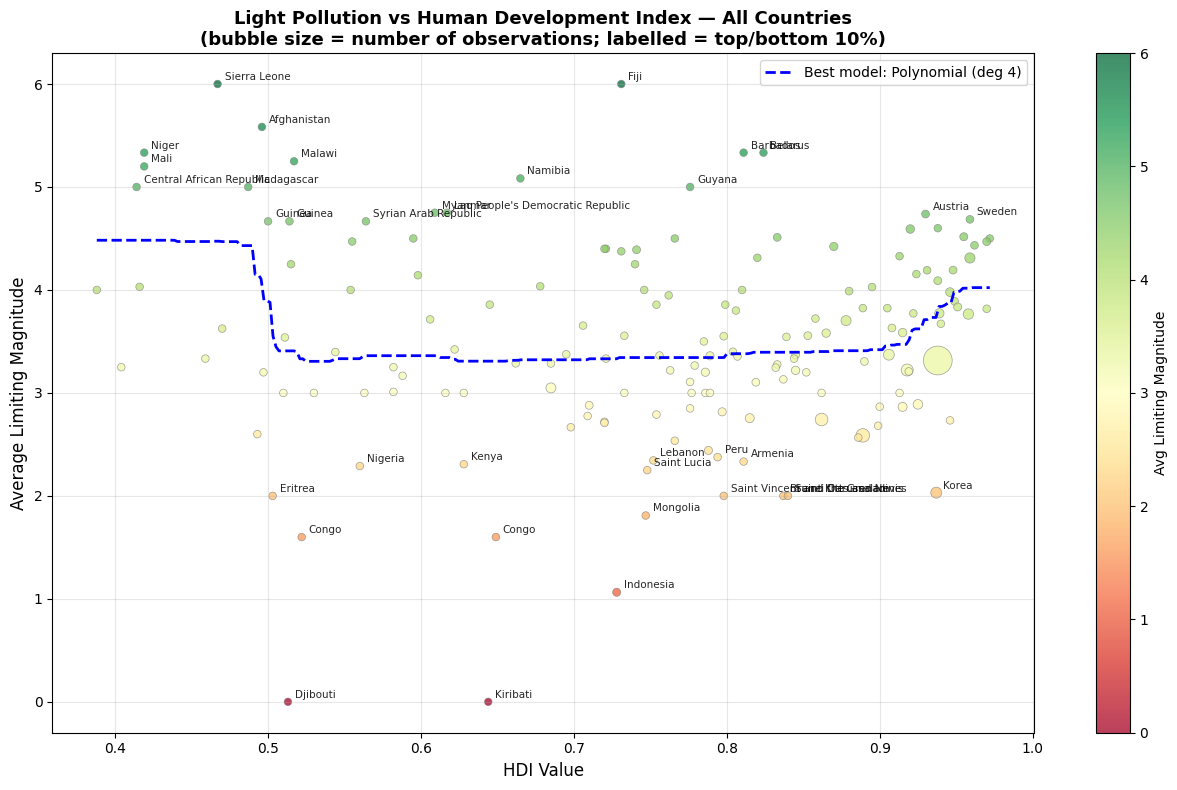

In [127]:
# ── 7c. Scatter: All countries labelled (top & bottom outliers) ──────────────
fig, ax = plt.subplots(figsize=(13, 8))

scatter = ax.scatter(
    country_plot['Value'], country_plot['LimitingMag'],
    c=country_plot['LimitingMag'], cmap='RdYlGn',
    s=country_plot['valid_data_points'] / country_plot['valid_data_points'].max() * 400 + 30,
    alpha=0.75, edgecolors='grey', linewidth=0.5
)
plt.colorbar(scatter, ax=ax, label='Avg Limiting Magnitude')

# Overlay best model fit
x_line = np.linspace(country_plot['Value'].min(), country_plot['Value'].max(), 300)
y_line = rf_best.predict(x_line.reshape(-1, 1))
ax.plot(x_line, y_line, 'b--', linewidth=2, label=f'Best model: {best_model_name}')

# Label extreme outliers
threshold_top    = country_plot['LimitingMag'].quantile(0.90)
threshold_bottom = country_plot['LimitingMag'].quantile(0.10)
outliers = country_plot[
    (country_plot['LimitingMag'] >= threshold_top) |
    (country_plot['LimitingMag'] <= threshold_bottom)
]
for _, row in outliers.iterrows():
    ax.annotate(row['Country'],
                xy=(row['Value'], row['LimitingMag']),
                xytext=(5, 3), textcoords='offset points',
                fontsize=7.5, alpha=0.85)

ax.set_xlabel('HDI Value', fontsize=12)
ax.set_ylabel('Average Limiting Magnitude', fontsize=12)
ax.set_title('Light Pollution vs Human Development Index — All Countries\n'
             '(bubble size = number of observations; labelled = top/bottom 10%)',
             fontsize=13, fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('all_countries_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Final Results Summary

In [128]:
# ── 8. Final Results Summary ─────────────────────────────────────────────────
print("=" * 70)
print("       FINAL RESEARCH RESULTS SUMMARY")
print("       Light Pollution (Limiting Magnitude) vs. HDI")
print("       Globe at Night Data (2006–2024)  ×  UNDP HDI")
print("=" * 70)

print(f"\n📊 Dataset")
print(f"   Countries analysed       : {len(country_plot)}")
print(f"   HDI range                : {country_plot['Value'].min():.3f} – {country_plot['Value'].max():.3f}")
print(f"   Limiting Mag range       : {country_plot['LimitingMag'].min():.2f} – {country_plot['LimitingMag'].max():.2f}")

print(f"\n🔬 Correlation Tests")
print(f"   Pearson  r = {pearson_r:+.4f}  (p = {pearson_p:.4e})")
print(f"   Spearman r = {spearman_r:+.4f}  (p = {spearman_p:.4e})")
dir_str = "NEGATIVE" if pearson_r < 0 else "POSITIVE"
print(f"   Direction: {dir_str} — higher HDI associated with",
      "worse (brighter) skies." if pearson_r < 0 else "darker skies.")

print(f"\n📈 Best Model: {best_model_name}")
best_row = results.iloc[0]
print(f"   Training R²  : {best_row['Train R²']:.4f}")
print(f"   CV R²        : {best_row['CV R²']:.4f}")
print(f"   Training RMSE: {best_row['Train RMSE']:.4f}")
print(f"   CV RMSE      : {best_row['CV RMSE']:.4f}")

print(f"\n🌍 Country Highlights")
darkest = country_plot.loc[country_plot['LimitingMag'].idxmax()]
brightest = country_plot.loc[country_plot['LimitingMag'].idxmin()]
print(f"   Darkest skies   : {darkest['Country']:25s} (LimMag={darkest['LimitingMag']:.2f}, HDI={darkest['Value']:.3f})")
print(f"   Most polluted   : {brightest['Country']:25s} (LimMag={brightest['LimitingMag']:.2f}, HDI={brightest['Value']:.3f})")

print(f"\n📉 HDI Quartile Means (Limiting Magnitude)")
for _, row in quartile_stats.iterrows():
    print(f"   {str(row['HDI_Quartile']):22s}: {row['mean']:.2f}")

print(f"\n   ANOVA: F={f_stat:.3f}, p={anova_p:.4f}",
      "→ Significant difference across quartiles." if anova_p < 0.05
      else "→ No significant difference across quartiles.")

print("\n" + "=" * 70)
print("  All models and visualisations saved to ")
print("=" * 70)


       FINAL RESEARCH RESULTS SUMMARY
       Light Pollution (Limiting Magnitude) vs. HDI
       Globe at Night Data (2006–2024)  ×  UNDP HDI

📊 Dataset
   Countries analysed       : 163
   HDI range                : 0.388 – 0.972
   Limiting Mag range       : 0.00 – 6.00

🔬 Correlation Tests
   Pearson  r = -0.0342  (p = 6.6503e-01)
   Spearman r = +0.0272  (p = 7.3007e-01)
   Direction: NEGATIVE — higher HDI associated with worse (brighter) skies.

📈 Best Model: Polynomial (deg 4)
   Training R²  : 0.0790
   CV R²        : 0.0293
   Training RMSE: 0.9303
   CV RMSE      : 0.9479

🌍 Country Highlights
   Darkest skies   : Fiji                      (LimMag=6.00, HDI=0.731)
   Most polluted   : Kiribati                  (LimMag=0.00, HDI=0.644)

📉 HDI Quartile Means (Limiting Magnitude)
   Low HDI (Q1)          : 3.73
   Medium-Low (Q2)       : 3.31
   Medium-High (Q3)      : 3.36
   High HDI (Q4)         : 3.70

   ANOVA: F=2.194, p=0.0908 → No significant difference across quartiles.
